# GAM-EWMA — 염소 분만 조기탐지


1. 전처리 데이터 로드
2. Outer GAM 학습 (26/1)
3. Inner pairwise GAM 학습 (25/1)
4. EWMA 산출 (λ는 고정값)
5. Inner validation에서 threshold 선택 (FA/Animal-Day≤2 제약 하 Event Recall 최대)
6. Outer Test 평가
7. 결과 집계 및 요약
8. 결과 저장 
9. 결과 시각화


In [ ]:
# =========================================================
# 경로 설정
# =========================================================
import os, time, warnings
from itertools import combinations

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from pygam import LogisticGAM, s

warnings.filterwarnings("ignore")

SAVE_DIR = r"C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset\processed"
PREPROCESS_SAVE_DIR = os.path.join(SAVE_DIR, "전처리")       # 전처리.ipynb 출력 위치
STAGE_SAVE_DIR = os.path.join(SAVE_DIR, "GAM_EWMA")          # 결과 저장 위치 

INPUT_CSV = os.path.join(PREPROCESS_SAVE_DIR, "goat_all_preprocessing.csv")   

In [2]:
# =========================================================
# Config
# =========================================================
SEED = 42
np.random.seed(SEED)

CFG = dict(
    # ---- 입력 컬럼 ----
    feature_cols=["O_30m", "D_15-30m", "MAD_15m", "Act15m", "Temp_60m"],
    target_col="y_H2",             

    # ---- 모델링 제외 개체 ----
    exclude_from_modeling={20},              
    exclude_from_event_metrics=set(),        

    # ---- 개체 그룹 ----
    mid_sensor_gap_goats={8, 11, 12, 15},                            # 관측 중간에 센서 결측 개체
    multi_birth_goats={2, 4, 6, 7, 8, 9, 11, 12, 16},                # 다중 분만 개체

    # ---- GAM 하이퍼파라미터 ----
    gam_n_splines=4,
    gam_spline_order=2,
    gam_lam=1,

    # ---- EWMA 하이퍼파라미터 ----
    ewma_lambda=0.05,

    # ---- 경보 평가 구간 ----
    h_hours=2.0,        
    far_min_hours=3.0,  

    # ---- threshold 후보 선택 기준 ----
    threshold_grid=np.round(np.arange(0.10, 0.70, 0.01), 2),
    fa_delta=2.0,       
)


In [3]:
# =========================================================
# [1] 전처리 데이터 로드
# =========================================================
combined_df = pd.read_csv(INPUT_CSV, parse_dates=["Datetime"])


def get_birth_time(d):
    """target(=y_H2)이 1인 마지막 분 + 1분 = 분만 시각. target이 계속 0(=분만 미관측, censored)이면 None."""
    pos_rows = d[d[CFG["target_col"]] == 1]
    return None if pos_rows.empty else pos_rows["Datetime"].max() + pd.Timedelta(minutes=1)


goats = {}
for gid, g in combined_df.groupby("goat_id"):
    g = g.sort_values("Datetime").reset_index(drop=True)
    bt = get_birth_time(g)
    g["birth_time"] = bt
    g["time_to_birth_hr"] = (bt - g["Datetime"]).dt.total_seconds() / 3600 if bt is not None else np.nan
    goats[int(gid)] = g

MODELING_GOATS = sorted(g for g in goats if g not in CFG["exclude_from_modeling"])

In [4]:
# =========================================================
# [2] GAM 학습 / 예측 함수 정의 (Outer·Inner 공용, [3]에서도 재사용)
# =========================================================
def build_terms(n_feat, n_splines, spline_order):
    """모든 입력변수를 spline term s()로 결합한다."""
    term = s(0, n_splines=n_splines, spline_order=spline_order)
    for j in range(1, n_feat):
        term = term + s(j, n_splines=n_splines, spline_order=spline_order)
    return term


def fit_gam(train_df, feature_cols=None):
    """fold Train(dropna 적용됨)만으로 GAM을 학습한다. GAM 설정은 CFG 고정값 사용."""
    feature_cols = feature_cols or CFG["feature_cols"]
    Xtr = train_df[feature_cols].to_numpy()
    ytr = train_df[CFG["target_col"]].to_numpy()
    terms = build_terms(len(feature_cols), CFG["gam_n_splines"], CFG["gam_spline_order"])
    return LogisticGAM(terms, lam=CFG["gam_lam"]).fit(Xtr, ytr)


def fit_gam_excluding(excluded_gids, feature_cols=None):
    """MODELING_GOATS에서 excluded_gids를 제외한 나머지 전체로 GAM을 학습한다."""
    feature_cols = feature_cols or CFG["feature_cols"]
    train_gids = [g for g in MODELING_GOATS if g not in excluded_gids]
    train_df = pd.concat([goats[g].dropna(subset=feature_cols) for g in train_gids], ignore_index=True)
    return fit_gam(train_df, feature_cols), train_gids


def predict_goat(gam, gid, feature_cols=None):
    """gid 개체의 전체 타임라인(dropna 적용)에 대해 risk_prob(분만 위험확률)을 산출한다."""
    feature_cols = feature_cols or CFG["feature_cols"]
    d = goats[gid].dropna(subset=feature_cols).reset_index(drop=True)
    risk_prob = gam.predict_proba(d[feature_cols].to_numpy())
    return dict(gid=gid, datetime=d["Datetime"].to_numpy(), risk_prob=risk_prob,
                y_true=d[CFG["target_col"]].to_numpy(), ttb=d["time_to_birth_hr"].to_numpy())


In [ ]:
# =========================================================
# Nested LOSO-CV
# =========================================================
# outer 개체 o에 대해: (1) 나머지 전체로 학습해 o의 out-of-fold risk_prob 산출
#                     (2) o를 제외한 나머지로 다시 inner LOSO를 돌려 threshold* 선택 (GAM·EWMA λ는 고정값)
#                     (3) 선택된 threshold를 o의 risk_prob에 단 한 번만 적용해 평가
# inner LOSO에 필요한 pairwise GAM은 outer마다 다시 학습하지 않고, 개체 전체 조합에 대해 한 번만 학습해 재사용한다.

# --- [2] Outer GAM 학습 (out-of-fold risk_prob 산출) ---------------------------
outer_predictions = {}   # gid -> predict_goat() 결과 (해당 개체를 제외하고 학습한 GAM의 예측)
for test_gid in MODELING_GOATS:
    gam, _ = fit_gam_excluding({test_gid})
    outer_predictions[test_gid] = predict_goat(gam, test_gid)


In [ ]:
# --- [3] Inner pairwise GAM 학습 ({outer, validation} 동시 제외) ---------------
# 개체 수가 많으면 조합 수(=nC2)가 커서 이 셀이 가장 오래 걸린다. 중간 출력은 없지만 정상 동작이다.
pairwise_predictions = {}  
pairs = list(combinations(MODELING_GOATS, 2))
for k, (a, b) in enumerate(pairs, 1):
    gam_ab, train_gids = fit_gam_excluding({a, b})
    assert a not in train_gids and b not in train_gids
    pairwise_predictions[(a, b)] = {a: predict_goat(gam_ab, a), b: predict_goat(gam_ab, b)}

def get_inner_record(outer_gid, val_gid):
    """outer=outer_gid일 때 inner validation 개체 val_gid의 예측({outer_gid,val_gid} 모두 제외하고 학습됨)."""
    key = (min(outer_gid, val_gid), max(outer_gid, val_gid))
    return pairwise_predictions[key][val_gid]


In [ ]:
# =========================================================
# [4] EWMA / 경보(alarm) 함수 정의
# =========================================================
def compute_ewma_score(risk_prob, lam):
    """causal EWMA: ewma_score_t = lam*risk_prob_t + (1-lam)*ewma_score_{t-1}, ewma_score_0 = 0."""
    x = np.asarray(risk_prob, dtype=float)
    ewma_score = np.empty(len(x), dtype=float)
    running = 0.0
    for i, xi in enumerate(x):
        running = lam * xi + (1 - lam) * running
        ewma_score[i] = running
    return ewma_score


def generate_alarm(ewma_score, threshold):
    """ewma_score가 threshold를 초과하면 alarm=1(binary prediction)."""
    return ewma_score > threshold


def get_alarm_episodes(alarm):
    """연속 True 구간(episode)의 (start_idx, end_idx) 리스트를 반환한다."""
    idx = np.where(alarm)[0]
    if idx.size == 0:
        return []
    breaks = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[breaks + 1]] if breaks.size else np.array([idx[0]])
    ends = np.r_[idx[breaks], idx[-1]] if breaks.size else np.array([idx[-1]])
    return list(zip(starts, ends))


def evaluate_alarm_events(ttb, alarm, H=None, far_min=None):
    """alarm(bool 배열) 기반 개체 단위 이벤트 판정.
    near=(0,H]: 처음 alarm 시 탐지, Lead Time 기록. far=(far_min,inf): 겹치는 episode는 FA 1건.
    (H,far_min]은 중립 buffer. exposure_min: FA/animal-day 분모(far 구간 관측 분)."""
    H = CFG["h_hours"] if H is None else H
    far_min = CFG["far_min_hours"] if far_min is None else far_min
    ttb = np.asarray(ttb, dtype=float)
    valid = ttb >= 0
    exposure_min = float((ttb > far_min).sum())
    if not valid.any():
        return False, np.nan, 0, exposure_min

    alarm_valid = np.asarray(alarm) & valid
    detected, lead_time, fa_episodes = False, np.nan, 0
    for s, e in get_alarm_episodes(alarm_valid):
        seg_ttb = ttb[s:e + 1]
        touches_far = np.any(seg_ttb > far_min)
        touches_near = np.any((seg_ttb > 0) & (seg_ttb <= H))
        if touches_far:
            fa_episodes += 1
        if touches_near and not detected:
            detected = True
            lead_time = float(seg_ttb[np.where((seg_ttb > 0) & (seg_ttb <= H))[0][0]])
    return detected, lead_time, fa_episodes, exposure_min


def compute_goat_alarm_metrics(ttb, risk_prob, lam, threshold, H=None, far_min=None):
    """단일 개체 EWMA+threshold 경보 판정 wrapper: ewma_score 계산 -> alarm 생성 -> 이벤트 평가."""
    ewma_score = compute_ewma_score(risk_prob, lam)
    alarm = generate_alarm(ewma_score, threshold)
    detected, lead_time, fa_episodes, exposure_min = evaluate_alarm_events(ttb, alarm, H, far_min)
    return detected, lead_time, fa_episodes, exposure_min, ewma_score, alarm

In [ ]:
# =========================================================
# [5] threshold 선택 + 평가지표 함수 정의
# GAM 하이퍼파라미터와 EWMA λ는 CFG 고정값을 사용하고(ROC-AUC 최대화로 탐색하지 않음),
# threshold만 inner LOSO에서 FA/Animal-Day<=fa_delta 제약 하 Event Recall 최대 기준으로 선택한다.
# =========================================================
def evaluate_threshold_grid(records, ewma_lambda, threshold_grid, H=None, far_min=None):
    """records=[{gid,ttb,risk_prob}, ...]에 대해 threshold 후보를 pooled 평가한다.
    ewma_lambda(고정값)로 만든 ewma_score는 threshold 후보 간 재계산하지 않고 재사용한다(반복 계산 축소).
    exclude_from_event_metrics 개체는 Recall/Lead Time에서 제외하되 FA/day에는 포함한다."""
    ewma_by_gid = {r["gid"]: compute_ewma_score(r["risk_prob"], ewma_lambda) for r in records}
    rows = []
    for threshold in threshold_grid:
        n_detect, n_total, lead_times = 0, 0, []
        fa_total, exposure_min_total = 0, 0.0
        for r in records:
            alarm = generate_alarm(ewma_by_gid[r["gid"]], threshold)
            detected, lead_time, fa_ep, exp_min = evaluate_alarm_events(r["ttb"], alarm, H, far_min)
            fa_total += fa_ep
            exposure_min_total += exp_min
            if r["gid"] in CFG["exclude_from_event_metrics"]:
                continue
            n_total += 1
            if detected:
                n_detect += 1
                lead_times.append(lead_time)
        rows.append(dict(
            threshold=threshold,
            event_recall=n_detect / n_total if n_total else np.nan,
            fa_per_day=fa_total / (exposure_min_total / 1440) if exposure_min_total > 0 else np.nan,
            mean_lead=float(np.mean(lead_times)) if lead_times else np.nan,
            median_lead=float(np.median(lead_times)) if lead_times else np.nan,
            n_detect=n_detect, n_total=n_total,
        ))
    return pd.DataFrame(rows)


def select_threshold(inner_records, threshold_grid=None, fa_delta=None, ewma_lambda=None):
    """FA/Animal-Day<=fa_delta 제약 하 Event Recall 최대 threshold를 선택한다.
    tie-break: Event Recall -> Lead Time -> FA/Animal-Day 순(동률 시 임의 선택 없음).
    제약을 만족하는 threshold가 없으면 FA/Animal-Day 최소 threshold로 대체하고 feasible=False로 표시한다."""
    threshold_grid = CFG["threshold_grid"] if threshold_grid is None else threshold_grid
    fa_delta = CFG["fa_delta"] if fa_delta is None else fa_delta
    ewma_lambda = CFG["ewma_lambda"] if ewma_lambda is None else ewma_lambda

    grid_df = evaluate_threshold_grid(inner_records, ewma_lambda, threshold_grid)
    feasible_df = grid_df[grid_df["fa_per_day"] <= fa_delta]
    if len(feasible_df) == 0:
        ranked = grid_df.sort_values(["fa_per_day", "event_recall", "mean_lead"], ascending=[True, False, False])
        feasible = False
    else:
        ranked = feasible_df.sort_values(["event_recall", "mean_lead", "fa_per_day"], ascending=[False, False, True])
        feasible = True
    chosen = ranked.iloc[0]
    return float(chosen["threshold"]), feasible, grid_df


def compute_pointwise_metrics(y_true, risk_prob, alarm):
    """Precision/Recall/F1(alarm vs target, 분 단위)과 ROC-AUC/PR-AUC(연속형 risk_prob vs target)를 계산한다.
    target이 한 클래스뿐이면 AUC는 정의되지 않으므로 NaN을 반환한다."""
    y_true = np.asarray(y_true).astype(int)
    alarm_bin = np.asarray(alarm).astype(int)
    metrics = dict(
        precision=precision_score(y_true, alarm_bin, zero_division=0),
        recall=recall_score(y_true, alarm_bin, zero_division=0),
        f1=f1_score(y_true, alarm_bin, zero_division=0),
    )
    if len(np.unique(y_true)) < 2:
        metrics.update(roc_auc=np.nan, pr_auc=np.nan)
    else:
        metrics.update(roc_auc=roc_auc_score(y_true, risk_prob), pr_auc=average_precision_score(y_true, risk_prob))
    return metrics


In [ ]:
# --- [4]EWMA산출(λ 고정) -> [5]Inner에서 threshold* 선택 -> [6]Outer Test 1회 평가 --------
fold_summaries, trace_rows = [], []

for o in MODELING_GOATS:
    inner_gids = [g for g in MODELING_GOATS if g != o]
    inner_records = []
    for v in inner_gids:
        rec = get_inner_record(o, v)
        inner_records.append(dict(gid=v, ttb=rec["ttb"], risk_prob=rec["risk_prob"]))

    threshold_star, feasible, _ = select_threshold(inner_records)

    outer_rec = outer_predictions[o]   # 나머지 개체 전체로 학습, o는 학습에 전혀 사용 안 됨
    detected, lead_time, fa_ep, exposure_min, ewma_score, alarm = compute_goat_alarm_metrics(
        outer_rec["ttb"], outer_rec["risk_prob"], CFG["ewma_lambda"], threshold_star)
    pointwise = compute_pointwise_metrics(outer_rec["y_true"], outer_rec["risk_prob"], alarm)

    birth_time = goats[o]["birth_time"].iloc[0]
    detection_time = birth_time - pd.Timedelta(hours=lead_time) if detected else pd.NaT

    fold_summaries.append(dict(
        test_goat=o,
        train_goats=",".join(map(str, inner_gids)),
        validation_scheme="inner LOSO over train_goats ({test_goat,val} excluded from that GAM fit)",
        gam_n_splines=CFG["gam_n_splines"], gam_spline_order=CFG["gam_spline_order"], gam_lam=CFG["gam_lam"],
        ewma_lambda=CFG["ewma_lambda"], threshold_star=threshold_star, feasible=feasible,
        detected=bool(detected), detection_time=detection_time, lead_time_hr=lead_time,
        fa_episodes=int(fa_ep), exposure_min=exposure_min,
        fa_per_day=(fa_ep / (exposure_min / 1440)) if exposure_min > 0 else np.nan,
        precision=pointwise["precision"], recall=pointwise["recall"], f1=pointwise["f1"],
        roc_auc=pointwise["roc_auc"], pr_auc=pointwise["pr_auc"],
    ))

    trace_rows.append(pd.DataFrame(dict(
        goat_id=o, Datetime=outer_rec["datetime"], time_to_birth_hr=outer_rec["ttb"], y_true=outer_rec["y_true"],
        risk_prob=outer_rec["risk_prob"], ewma_score=ewma_score, alarm=alarm.astype(int),
        threshold_star=threshold_star,
    )))

outer_results_df = pd.DataFrame(fold_summaries)
trace_df = pd.concat(trace_rows, ignore_index=True)


In [ ]:
# =========================================================
# 개체(outer fold)별 임계값
# =========================================================
ts = outer_results_df["threshold_star"]
print(f"\n[threshold* 범위] min={ts.min():.2f}  max={ts.max():.2f}  "
      f"median={ts.median():.2f}  IQR=[{ts.quantile(0.25):.2f}, {ts.quantile(0.75):.2f}]  "
      f"(전체 {ts.nunique()}종류, {len(ts)}개 fold)")

print("\n[선택 빈도] threshold_star")
threshold_choice_counts = (outer_results_df["threshold_star"].value_counts()
                           .rename_axis("threshold_star").reset_index(name="n_folds")
                           .sort_values("threshold_star"))
print(threshold_choice_counts.to_string(index=False))
print("=" * 70)


[threshold* 범위] min=0.30  max=0.37  median=0.35  IQR=[0.33, 0.36]  (전체 6종류, 26개 fold)

[선택 빈도] threshold_star
 threshold_star  n_folds
           0.30        6
           0.33        1
           0.34        4
           0.35        8
           0.36        6
           0.37        1


In [ ]:
# =========================================================
# [7] 결과 집계 및 요약
# =========================================================
eligible_df = outer_results_df[~outer_results_df["test_goat"].isin(CFG["exclude_from_event_metrics"])]
detected_lead_times = eligible_df.loc[eligible_df["detected"], "lead_time_hr"]

overall_event_recall = eligible_df["detected"].mean()
overall_fa_per_animal_day = outer_results_df["fa_episodes"].sum() / (outer_results_df["exposure_min"].sum() / 1440)
overall_median_lead = float(detected_lead_times.median()) if len(detected_lead_times) else np.nan

trace_eligible = trace_df[~trace_df["goat_id"].isin(CFG["exclude_from_event_metrics"])]
overall_precision = precision_score(trace_eligible["y_true"], trace_eligible["alarm"], zero_division=0)
overall_recall = recall_score(trace_eligible["y_true"], trace_eligible["alarm"], zero_division=0)
overall_f1 = f1_score(trace_eligible["y_true"], trace_eligible["alarm"], zero_division=0)
overall_roc_auc = roc_auc_score(trace_eligible["y_true"], trace_eligible["risk_prob"])
overall_pr_auc = average_precision_score(trace_eligible["y_true"], trace_eligible["risk_prob"])

overall_summary_df = pd.DataFrame([dict(
    n_goats_total=len(eligible_df), 
    n_goats_detected=int(eligible_df["detected"].sum()),
    event_recall=overall_event_recall, 
    fa_per_animal_day=overall_fa_per_animal_day,
    lead_time_median_hr=overall_median_lead,
    precision=overall_precision, 
    recall=overall_recall, 
    f1=overall_f1,
    roc_auc=overall_roc_auc, 
    pr_auc=overall_pr_auc,
)])

# ---- 개체 그룹별 Event Recall(다중분만 / 중간 센서결측 / 일반개체 / 전체개체) ----
special_goats = CFG["mid_sensor_gap_goats"] | CFG["multi_birth_goats"]
goat_groups = {
    "전체개체": set(eligible_df["test_goat"]),
    "일반개체": set(eligible_df["test_goat"]) - special_goats,
    "다중분만 개체": set(eligible_df["test_goat"]) & CFG["multi_birth_goats"],
    "중간 센서결측 개체": set(eligible_df["test_goat"]) & CFG["mid_sensor_gap_goats"],
}
group_summary_df = pd.DataFrame([
    dict(group=name, goat_ids=",".join(map(str, sorted(gids))) if gids else "-",
         n_goats=len(gids), n_detected=int(eligible_df[eligible_df["test_goat"].isin(gids)]["detected"].sum()),
         event_recall=eligible_df[eligible_df["test_goat"].isin(gids)]["detected"].mean() if gids else np.nan,
         detected_goat_ids=",".join(map(str, sorted(eligible_df[eligible_df["test_goat"].isin(gids) & eligible_df["detected"]]["test_goat"]))) or "-")
    for name, gids in goat_groups.items()
])

In [ ]:
# =========================================================
# [7] 최종 요약 출력
# =========================================================
print("=" * 70)
print(f"전체 개체 수                 : {overall_summary_df['n_goats_total'].iloc[0]}")
print(f"탐지 성공 개체 수            : {overall_summary_df['n_goats_detected'].iloc[0]}")
print(f"Event Recall                 : {overall_event_recall:.2f}")
print(f"Lead Time 중앙값(탐지 개체): {overall_median_lead:.2f} hr")
print(f"FA/Animal-Day                : {overall_fa_per_animal_day:.2f}  (제약 fa_delta={CFG['fa_delta']})")
print(f"Precision                    : {overall_precision:.2f}")
print(f"Recall                       : {overall_recall:.2f}")
print(f"F1                           : {overall_f1:.2f}")
print(f"ROC-AUC                      : {overall_roc_auc:.2f}")
print(f"PR-AUC                       : {overall_pr_auc:.2f}")
print("=" * 70)

print("\n[그룹별 Event Recall]")
for _, row in group_summary_df.iterrows():
    print(f"  {row['group']:14s}: {row['n_detected']}/{row['n_goats']} = {row['event_recall']:.2f}"
          f" \n \t(개체: {row['goat_ids']}) \n \t(탐지된 개체: {row['detected_goat_ids']})")
print("=" * 70)

print(f"\n[GAM/EWMA 고정 하이퍼파라미터] n_splines={CFG['gam_n_splines']}, "
      f"spline_order={CFG['gam_spline_order']}, gam_lam={CFG['gam_lam']}, ewma_lambda={CFG['ewma_lambda']}")


overall_summary_df.round(2)


전체 개체 수                 : 26
탐지 성공 개체 수            : 16
Event Recall                 : 0.62
Lead Time 중앙값(탐지 개체): 1.60 hr
FA/Animal-Day                : 2.01  (제약 fa_delta=2.0)
Precision                    : 0.47
Recall                       : 0.37
F1                           : 0.41
ROC-AUC                      : 0.75
PR-AUC                       : 0.44

[그룹별 Event Recall]
  전체개체          : 16/26 = 0.62 
 	(개체: 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,23,24,25,26,27,28) 
 	(탐지된 개체: 2,5,7,10,13,14,15,16,17,18,19,21,24,25,27,28)
  일반개체          : 12/16 = 0.75 
 	(개체: 1,3,5,10,13,14,17,18,19,21,23,24,25,26,27,28) 
 	(탐지된 개체: 5,10,13,14,17,18,19,21,24,25,27,28)
  다중분만 개체       : 3/9 = 0.33 
 	(개체: 2,4,6,7,8,9,11,12,16) 
 	(탐지된 개체: 2,7,16)
  중간 센서결측 개체    : 1/4 = 0.25 
 	(개체: 8,11,12,15) 
 	(탐지된 개체: 15)

[GAM/EWMA 고정 하이퍼파라미터] n_splines=4, spline_order=2, gam_lam=1, ewma_lambda=0.05


,n_goats_total,n_goats_detected,event_recall,fa_per_animal_day,lead_time_median_hr,precision,recall,f1,roc_auc,pr_auc
0,26,16,0.62,2.01,1.6,0.47,0.37,0.41,0.75,0.44


In [ ]:
# =========================================================
# [8] 결과 저장
# =========================================================
TRACES_CSV = os.path.join(STAGE_SAVE_DIR, "GAM_EWMA_results.csv")
trace_df.to_csv(TRACES_CSV, index=False)
print(f"저장 완료 -> {TRACES_CSV} ({len(trace_df)} rows)")

저장 완료 -> C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset\processed\GAM_EWMA\GAM_EWMA_results.csv (19006 rows)


In [ ]:
# =========================================================
# [9] 결과 시각화 — 그림6(전체 Z_t 궤적) / 그림7(개체별 탐지 성공 사례)
# =========================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform


def setup_korean_font():
    system = platform.system()
    candidates = ["Malgun Gothic"] if system == "Windows" else ["AppleGothic"] if system == "Darwin" \
        else ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK JP"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            return
setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = os.path.join(STAGE_SAVE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
H_HOURS = CFG["h_hours"]

outer_lookup = outer_results_df.set_index("test_goat")
alarm_traces = {}
for gid, g in trace_df.groupby("goat_id"):
    row = outer_lookup.loc[gid]
    alarm_traces[int(gid)] = dict(
        ttb=g["time_to_birth_hr"].to_numpy(),
        p_hat=g["risk_prob"].to_numpy(),
        Z=g["ewma_score"].to_numpy(),
        c=float(g["threshold_star"].iloc[0]),
        lead_time=row["lead_time_hr"],
        detected=bool(row["detected"]),
    )


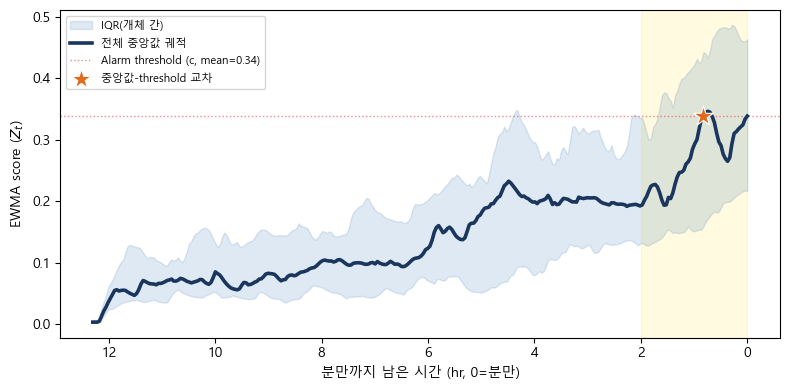

In [ ]:
# =========================================================
# 그림6(전체 Z_t 궤적)
# =========================================================
def plot_ewma_overview():
    '''전체 개체 EWMA 점수(Z_t) 궤적: 전체 중앙값(굵은 선) + IQR 음영'''
    grid = np.linspace(12.3, 0, 300)
    Z_grid_all = []

    fig, ax = plt.subplots(figsize=(8, 4))
    for gid, info in alarm_traces.items():
        ttb, Z = info["ttb"], info["Z"]
        order = np.argsort(-ttb)
        ttb_s, Z_s = ttb[order], Z[order]
        mask = (ttb_s >= 0) & (ttb_s <= 13)
        if mask.sum() < 2:
            continue
        Zg = np.interp(grid, ttb_s[mask][::-1], Z_s[mask][::-1])
        Z_grid_all.append(Zg)

    Z_grid_all = np.array(Z_grid_all)
    median_Z = np.median(Z_grid_all, axis=0)
    q1, q3 = np.percentile(Z_grid_all, [25, 75], axis=0)

    ax.fill_between(grid, q1, q3, color="#2b6cb0", alpha=0.15, zorder=2, label="IQR(개체 간)")
    ax.plot(grid, median_Z, color="#1a365d", lw=2.6, zorder=3, label="전체 중앙값 궤적")

    c_mean = outer_results_df["threshold_star"].mean()
    ax.axhline(c_mean, color="#e53e3e", ls=":", lw=1.0, alpha=0.6,
               label=f"Alarm threshold (c, mean={c_mean:.2f})")
    ax.axvspan(0, H_HOURS, color="gold", alpha=0.12, zorder=0)

    diff = median_Z - c_mean
    cross_idx = np.where((diff[:-1] < 0) & (diff[1:] >= 0))[0]
    if cross_idx.size > 0:
        j = cross_idx[0]
        x0, x1 = grid[j], grid[j + 1]
        y0, y1 = median_Z[j], median_Z[j + 1]
        t_frac = (c_mean - y0) / (y1 - y0)
        x_star = x0 + t_frac * (x1 - x0)
        ax.scatter([x_star], [c_mean], marker="*", s=220, color="#dd6b20", zorder=6,
                   edgecolor="white", linewidth=0.8, label="중앙값-threshold 교차")

    ax.invert_xaxis()
    ax.set_xlabel("분만까지 남은 시간 (hr, 0=분만)")
    ax.set_ylabel(r"EWMA score ($Z_t$)")
    ax.legend(fontsize=8, loc="upper left")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "ewma_overview_all_goats.png"), dpi=600, bbox_inches="tight")
    plt.show()

plot_ewma_overview()


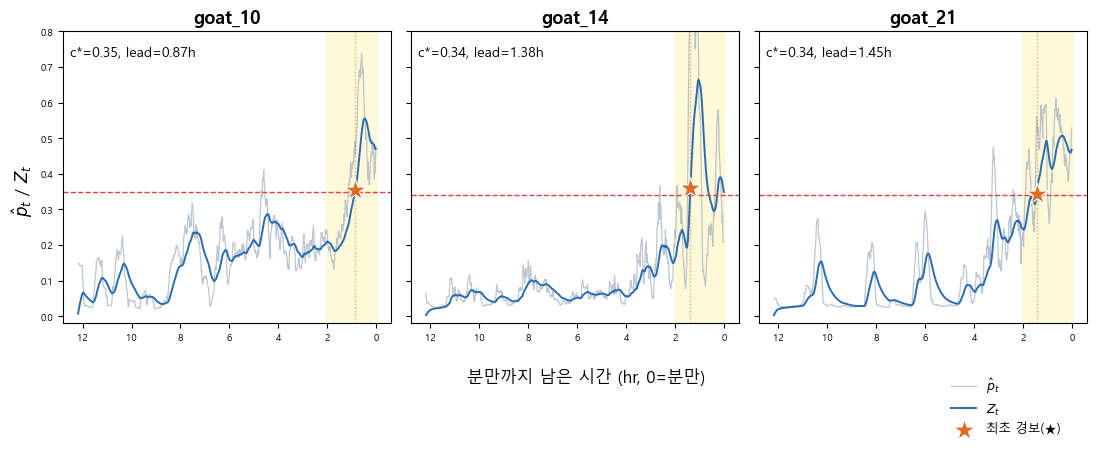

In [ ]:
# =========================================================
# 그림7(개체별 탐지 성공 사례 - 3개체)
# =========================================================
SELECTED_GOATS = [10, 14, 21]

def plot_detection_success_examples(gids):
    ncols = len(gids)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), sharey=True)
    axes = np.atleast_1d(axes)

    p_line = z_line = alarm_marker = None
    for ax, gid in zip(axes, gids):
        info = alarm_traces[gid]   # 위에서 만든 결과에서 그대로 조회(재계산 없음)
        ttb, p_hat, Z, c = info["ttb"], info["p_hat"], info["Z"], info["c"]
        order = np.argsort(-ttb)

        (p_line,) = ax.plot(ttb[order], p_hat[order], color="#a0aec0", alpha=0.7, lw=0.9, label=r"$\hat p_t$")
        (z_line,) = ax.plot(ttb[order], Z[order], color="#2b6cb0", lw=1.4, label=r"$Z_t$")
        ax.axhline(c, color="#e53e3e", ls="--", lw=1.0)

        ax.axvspan(0, H_HOURS, color="gold", alpha=0.15)

        if info["detected"]:
            lt = info["lead_time"]
            ax.axvline(lt, color="#dd6b20", ls=":", lw=1.0, alpha=0.6)
            idx_lt = np.argmin(np.abs(ttb - lt))
            alarm_marker = ax.scatter([lt], [Z[idx_lt]], marker="*", s=260, color="#dd6b20",
                                       edgecolor="white", linewidth=0.8, zorder=6, label="최초 경보(조기탐지)")

        ax.invert_xaxis()
        ax.set_title(f"goat_{gid:02d}", fontsize=13, fontweight="bold")
        ax.set_ylim(-0.02, 0.8)
        ax.tick_params(labelsize=7)
        info_txt = f"c*={c:.2f}"
        if info["detected"]:
            info_txt += f", lead={info['lead_time']:.2f}h"
        ax.text(0.02, 0.95, info_txt, transform=ax.transAxes, fontsize=10, va="top")

    fig.supxlabel("분만까지 남은 시간 (hr, 0=분만)")
    fig.supylabel(r"$\hat p_t$ / $Z_t$")
    legend_handles = [h for h in [p_line, z_line, alarm_marker] if h is not None]
    legend_labels = [r"$\hat p_t$", r"$Z_t$"] + (["최초 경보(★)"] if alarm_marker is not None else [])
    fig.legend(legend_handles, legend_labels, loc="center", bbox_to_anchor=(0.85, -0.04),
               fontsize=9, frameon=False)
    fig.tight_layout(rect=[0, 0, 0.93, 0.99])
    fig.savefig(os.path.join(FIG_DIR, "detection_success_examples.png"), dpi=600, bbox_inches="tight")
    plt.show()


plot_detection_success_examples(SELECTED_GOATS)
